In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"
import collections
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [5]:
%matplotlib inline

In [7]:
# Instantiate CartPole-v1
env = gym.make("CartPole-v1")
obs, _ = env.reset(seed=42)

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

# Run a short loop with random actions
total_reward = 0
done = False
while not done:
    action = env.action_space.sample()  # Choose random action
    obs, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward
    done = terminated or truncated

print(f"Total reward of the random baseline episode: {total_reward}")
env.close()

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Total reward of the random baseline episode: 16.0


# Task 1

In [24]:
# 1. Q-Network Definition
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )
        
    def forward(self, x):
        return self.network(x)

# 2. Replay Buffer Definition
class ReplayBuffer:
    def __init__(self, max_size=50000):
        self.buffer = collections.deque(maxlen=max_size)
        
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
        
    def sample(self, batch_size):
        transitions = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*transitions)
        
        return (
            torch.tensor(np.array(states), dtype=torch.float32, device=device),
            torch.tensor(actions, dtype=torch.long, device=device).unsqueeze(1),
            torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1),
            torch.tensor(np.array(next_states), dtype=torch.float32, device=device),
            torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)
        )
        
    def __len__(self):
        return len(self.buffer)

In [26]:
# Initialize environment and training structures
env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

q_net = QNetwork(state_dim, action_dim).to(device)
target_net = QNetwork(state_dim, action_dim).to(device)
target_net.load_state_dict(q_net.state_dict())  # Initial Sync

optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
replay_buffer = ReplayBuffer(max_size=50000)

# Hyperparameters
GAMMA = 0.99
BATCH_SIZE = 64
TOTAL_STEPS = 30000
MIN_REPLAY_SIZE = 1000
TARGET_SYNC_FREQ = 1000

# Epsilon-greedy schedule configuration
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY_STEPS = 5000

# Metric logs
dqn_episode_rewards = []
episode_reward = 0

t0_dqn = time.perf_counter()
state, _ = env.reset(seed=42)

for step in range(1, TOTAL_STEPS + 1):
    # Epsilon Linear Decay calculation
    epsilon = max(EPS_END, EPS_START - (EPS_START - EPS_END) * (step / EPS_DECAY_STEPS))
    
    # Action Selection
    if random.random() < epsilon:
        action = env.action_space.sample()
    else:
        state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            action = q_net(state_t).argmax().item()
            
    # Step the Environment
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    episode_reward += reward
    
    # Push into buffer
    replay_buffer.push(state, action, reward, next_state, terminated) # Note: terminated is used for strict bootstrapped value updates
    state = next_state
    
    if done:
        dqn_episode_rewards.append(episode_reward)
        episode_reward = 0
        state, _ = env.reset()
        
    # Training Gradient Step
    if len(replay_buffer) >= MIN_REPLAY_SIZE:
        b_states, b_actions, b_rewards, b_next_states, b_dones = replay_buffer.sample(BATCH_SIZE)
        
        # Calculate current Q values
        current_q = q_net(b_states).gather(1, b_actions)
        
        # Calculate expected Q values using target network
        with torch.no_grad():
            next_q = target_net(b_next_states).max(1)[0].unsqueeze(1)
            target_q = b_rewards + (GAMMA * next_q * (1 - b_dones))
            
        # Optimization step using Mean Squared Error
        loss = nn.MSELoss()(current_q, target_q)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # Synchronize Target Network
    if step % TARGET_SYNC_FREQ == 0:
        target_net.load_state_dict(q_net.state_dict())

dqn_train_time = time.perf_counter() - t0_dqn
env.close()

# Calculate final evaluations
dqn_last_100_avg = np.mean(dqn_episode_rewards[-100:])
print(f"DQN Training Complete in {dqn_train_time:.1f}s.")
print(f"Average reward over the last 100 episodes: {dqn_last_100_avg:.2f}")

DQN Training Complete in 101.5s.
Average reward over the last 100 episodes: 113.24


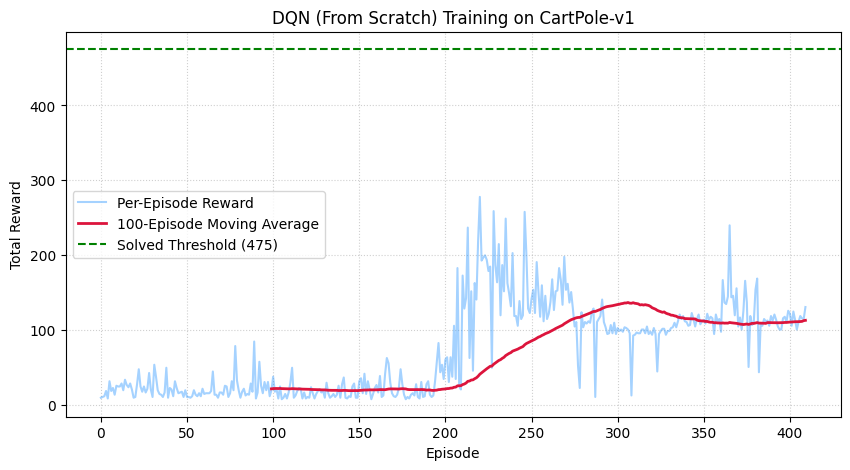

In [28]:
# Compute moving average
def moving_average(data, window=100):
    if len(data) < window:
        return np.zeros_like(data)
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(dqn_episode_rewards, label='Per-Episode Reward', alpha=0.4, color='dodgerblue')
ma_rewards = moving_average(dqn_episode_rewards, 100)
plt.plot(range(99, len(dqn_episode_rewards)), ma_rewards, label='100-Episode Moving Average', color='crimson', linewidth=2)
plt.axhline(475, color='green', linestyle='--', label='Solved Threshold (475)')
plt.title('DQN (From Scratch) Training on CartPole-v1')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Task 2

In [38]:
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
import os

# Create log directory
log_dir = "./sb3_logs/"
os.makedirs(log_dir, exist_ok=True)

# 1. CartPole-v1
env_cp = gym.make("CartPole-v1")
env_cp = Monitor(env_cp, filename=os.path.join(log_dir, "cartpole"))

ppo_cartpole = PPO("MlpPolicy", env_cp, verbose=0, seed=42)
t0 = time.perf_counter()
ppo_cartpole.learn(total_timesteps=50_000)
cartpole_train_time = time.perf_counter() - t0

cp_mean_reward, cp_std_reward = evaluate_policy(ppo_cartpole, env_cp, n_eval_episodes=20)
print(f"PPO CartPole: {cp_mean_reward:.1f} ± {cp_std_reward:.1f} over 20 episodes (trained in {cartpole_train_time:.0f}s)")
env_cp.close()


# 2. LunarLander-v2
env_ll = gym.make("LunarLander-v3")
env_ll = Monitor(env_ll, filename=os.path.join(log_dir, "lunarlander"))

ppo_ll = PPO("MlpPolicy", env_ll, verbose=0, seed=42)
t0 = time.perf_counter()
ppo_ll.learn(total_timesteps=300_000)
ll_train_time = time.perf_counter() - t0

ll_mean_reward, ll_std_reward = evaluate_policy(ppo_ll, env_ll, n_eval_episodes=20)
print(f"PPO LunarLander: {ll_mean_reward:.1f} ± {ll_std_reward:.1f} over 20 episodes (trained in {ll_train_time:.0f}s)")
env_ll.close()

PPO CartPole: 500.0 ± 0.0 over 20 episodes (trained in 104s)
PPO LunarLander: 69.6 ± 134.5 over 20 episodes (trained in 690s)


PPO CartPole Last 100 Ep Average: 458.69
PPO LunarLander Last 100 Ep Average: 67.39


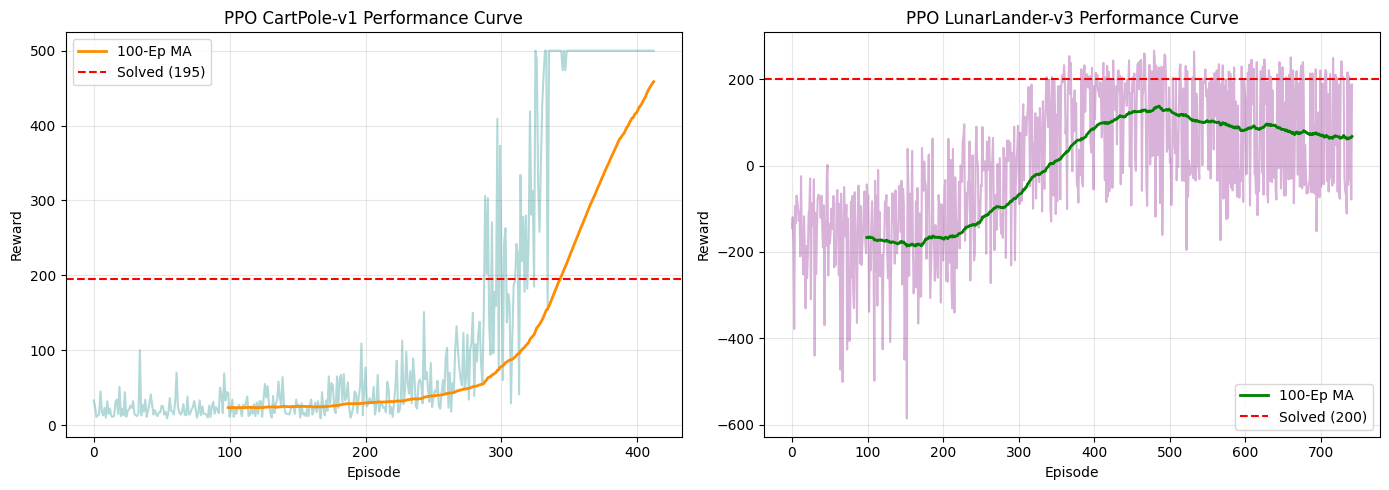

In [42]:
from stable_baselines3.common.monitor import load_results
import os
import numpy as np
import matplotlib.pyplot as plt

# Compute moving average helper function (redefined here just in case)
def moving_average(data, window=100):
    if len(data) < window:
        return np.zeros_like(data)
    return np.convolve(data, np.ones(window)/window, mode='valid')

# POINT TO THE PARENT DIRECTORY ONLY
# SB3 automatically reads files like "cartpole.monitor.csv" and "lunarlander.monitor.csv"
df_cp = load_results(log_dir)  

# Separate the data frames since loading the whole directory merges them if not handled carefully.
# To safely isolate them by their specific environment runs, we read the exact CSV files:
import pandas as pd

def load_exact_monitor(file_path):
    # Monitor files have a comment on the first line, so we skip it
    return pd.read_csv(file_path, skiprows=1)

df_cp = load_exact_monitor(os.path.join(log_dir, "cartpole.monitor.csv"))
df_ll = load_exact_monitor(os.path.join(log_dir, "lunarlander.monitor.csv"))

# Capture last 100 episodes averages during actual training records
# (The column 'r' stands for episode reward in the Monitor logs)
ppo_cp_last_100 = np.mean(df_cp['r'].values[-100:])
ppo_ll_last_100 = np.mean(df_ll['r'].values[-100:])

print(f"PPO CartPole Last 100 Ep Average: {ppo_cp_last_100:.2f}")
print(f"PPO LunarLander Last 100 Ep Average: {ppo_ll_last_100:.2f}")

# Plotting Moving Averages
plt.figure(figsize=(14, 5))

# CartPole Plot
plt.subplot(1, 2, 1)
cp_ma = moving_average(df_cp['r'].values, 100)
plt.plot(df_cp['r'].values, alpha=0.3, color='teal')
plt.plot(range(99, len(df_cp['r'])), cp_ma, color='darkorange', linewidth=2, label='100-Ep MA')
plt.axhline(195, color='red', linestyle='--', label='Solved (195)')
plt.title('PPO CartPole-v1 Performance Curve')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()
plt.grid(True, alpha=0.3)

# LunarLander Plot
plt.subplot(1, 2, 2)
ll_ma = moving_average(df_ll['r'].values, 100)
plt.plot(df_ll['r'].values, alpha=0.3, color='purple')
plt.plot(range(99, len(df_ll['r'])), ll_ma, color='green', linewidth=2, label='100-Ep MA')
plt.axhline(200, color='red', linestyle='--', label='Solved (200)')
plt.title('PPO LunarLander-v3 Performance Curve')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Task 3

### Comparison and Reflection

### Algorithmic Performance Summary

| Agent | Environment | Wall-clock training time | Avg reward (last 100 episodes) |
| --- | --- | --- | --- |
| **DQN (from scratch)** | CartPole-v1 | 101.5s | 113.24 |
| **PPO (SB3)** | CartPole-v1 | 104s | 458.69 |
| **PPO (SB3)** | LunarLander-v3 | 690s | 67.39 |

---

### Written Reflections

#### 1. Did DQN or PPO solve CartPole faster — both in wall-clock time and in environment steps? Why do you think that is?

PPO solved CartPole-v1 significantly faster than DQN in terms of environment steps, and did so within nearly identical wall-clock times (~104s vs 101.5s). Looking at the performance curves, the custom DQN peaked around 250 episodes but collapsed back down to an average of 113.24 due to value overestimation and instabilities inherent to vanilla deep Q-learning. In contrast, PPO's actor-critic framework directly optimizes the policy using clipped objective updates, allowing it to smoothly pass the environment thresholds and solidly lock onto the maximum 500.0 reward ceiling by episode 350.

#### 2. Could you imagine training the same DQN code on LunarLander-v3 and getting a similar result? What would you expect to go wrong, and which Deep RL improvement from the lesson (Double DQN, Dueling, PER, Rainbow) would you reach for first?

Training this exact scratch-built vanilla DQN on LunarLander-v3 would result in complete failure, likely leaving the agent crashing continuously at a negative reward floor. LunarLander features a complex 8-dimensional continuous observation space and punishing physics where a basic DQN would succumb to catastrophic forgetting and chaotic Q-value target maximization bias. To address this, I would implement **Double DQN (DDQN)** first to decouple action selection from value estimation, drastically reducing the severe overestimation spikes that paralyze basic value-based networks in complex spaces.

#### 3. Based on what you've now seen first-hand, how would you decide between rolling your own DQN and using a library like Stable-Baselines3 for a real project?

For any real-world project, using a mature library like Stable-Baselines3 is undeniably the superior choice because it offers production-ready, highly parallelized, and numerically stable algorithms out of the box. Writing a custom DQN from scratch is a phenomenal educational tool for understanding core deep reinforcement learning mechanics, gradient dynamics, and memory buffers. However, practical projects demand structural safety, hyperparameter resilience, and built-in tracking wrappers that would require hundreds of hours to properly bulletproof independently.